# E-Commerce Clickstream Data Analytics

## Setup and Imports

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import datetime
import warnings
from decimal import Decimal

import matplotlib.pyplot as plt
import numpy as np

# Importing necessary libraries

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)

import lightgbm as lgb

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Define file paths

In [3]:
clicks_file = "data/yoochoose-data/yoochoose-clicks.dat"
buys_file = "data/yoochoose-data/yoochoose-buys.dat"

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12


SAMPLE_MODE = False  
MAX_CHUNKS = 50  
SAMPLE_SESSIONS = 1000  

print("Setup complete!")
print(
    f"Sampling mode: {'ON - Using a subset of data for testing' if SAMPLE_MODE else 'OFF - Using full dataset'}"
)

if SAMPLE_MODE:
    print(
        f"Processing max {MAX_CHUNKS} chunks with up to {SAMPLE_SESSIONS} sessions per chunk"
    )

Setup complete!
Sampling mode: OFF - Using full dataset


## Helper Functions

In [5]:
def convert_category(x):
    """
    Handle Category column in the clicks data (Numerical Encoding 1-12 for Category of Items)
    """
    if x == "S":
        return -1
    elif x in ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"]:
        return x
    else:
        return 13


def check_item_in_purchases(first_item, last_item, unique_items_bought, is_buy):
    """
    Check if first or last clicked item is in the set of purchased items
    """
    if is_buy == 1:
        if first_item in unique_items_bought or last_item in unique_items_bought:
            return True
    return False


def get_preds(threshold, probabilities):
    """
    Convert probabilities to binary predictions based on threshold
    """
    return [1 if prob > threshold else 0 for prob in probabilities]


def calc_special_offer_click(categories):
    """
    Determine if a session included a special offer click
    """
    if -1 in categories:
        return 1
    else:
        return 0


def p_root(value, root):
    """
    Calculate p-root of a value
    """
    root_value = 1 / float(root)
    return round(Decimal(value) ** Decimal(root_value), 3)


def minkowski_distance(x, y, p_value):
    """
    Calculate Minkowski distance between two vectors
    """
    return p_root(sum(pow(abs(a - b), p_value) for a, b in zip(x, y)), p_value)

## Data Loading

In [ ]:
print("Loading buys data...")

buys = pd.read_csv(buys_file, names=["session", "timestamp", "item_id", "price", "qty"])

print("Setting up columns for clicks data...")
clicks_columns = ["session", "timestamp", "item_id", "category"]

print(f"Buys data shape: {buys.shape}")
print(buys.head())

Loading buys data...
Setting up columns for clicks data...
Buys data shape: (1150753, 5)
   session                 timestamp    item_id  price  qty
0   420374  2014-04-06T18:44:58.314Z  214537888  12462    1
1   420374  2014-04-06T18:44:58.325Z  214537850  10471    1
2   281626  2014-04-06T09:40:13.032Z  214535653   1883    1
3   420368  2014-04-04T06:13:28.848Z  214530572   6073    1
4   420368  2014-04-04T06:13:28.858Z  214835025   2617    1


## Data Exploration - Buys

In [7]:
print("Exploring buys data...")

top_bought_items = buys["item_id"].value_counts().nlargest(10)
fig = px.bar(
    x=top_bought_items.index.astype(str),
    y=top_bought_items.values,
    title="Top 10 Items with Maximum Purchases",
    labels={"x": "Item ID", "y": "Count"}
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

Exploring buys data...


In [ ]:
quantity_analysis = (
    buys.groupby("item_id")["qty"].sum().sort_values(ascending=False).nlargest(10)
)
fig = px.bar(
    x=quantity_analysis.index.astype(str),
    y=quantity_analysis.values,
    title="Top 10 Items Purchased in Larger Quantities",
    labels={"x": "Item ID", "y": "Total Quantity"}
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [ ]:
price_analysis = (
    buys[["item_id", "price"]]
    .drop_duplicates()
    .sort_values("price", ascending=False)
    .nlargest(10, "price")
)
fig = px.bar(
    x=price_analysis["item_id"].astype(str),
    y=price_analysis["price"],
    title="Top 10 Items with Highest Prices",
    labels={"x": "Item ID", "y": "Price"}
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

## Transforming Buys Data

In [ ]:
print("Transforming buys data...")

grouped_buys = buys.groupby("session")
buys_transformed = pd.DataFrame(index=grouped_buys.groups.keys())


buys_transformed["Number_items_bought"] = grouped_buys.item_id.count()
buys_transformed["unique_items_bought"] = grouped_buys.item_id.apply(
    lambda x: list(x.unique())
)
buys_transformed["is_buy"] = 1
buys_transformed.index.name = "session"

print("Buys transformation complete")
print(buys_transformed.head())

Transforming buys data...
Buys transformation complete
         Number_items_bought                unique_items_bought  is_buy
session                                                                
11                         2                        [214821371]       1
12                         1                        [214717867]       1
21                         2             [214548744, 214838503]       1
33                         6  [214834865, 214706441, 214820225]       1
46                         2                        [214716932]       1


## Loading and Transforming Clicks Data (in chunks)

In [ ]:
print("Processing clicks data in chunks (session timing analysis)...")
result_timing = None
count = 1

for chunk in pd.read_csv(
    clicks_file,
    names=clicks_columns,
    usecols=["session", "timestamp", "item_id", "category"],
    parse_dates=["timestamp"],
    chunksize=500000,
):
    print(f"Processing chunk {count} for timing analysis...")

    
    if SAMPLE_MODE:
        unique_sessions = chunk["session"].unique()
        if len(unique_sessions) > SAMPLE_SESSIONS:
            sample_sessions = np.random.choice(
                unique_sessions, SAMPLE_SESSIONS, replace=False
            )
            chunk = chunk[chunk["session"].isin(sample_sessions)]

    
    chunk_grouped = chunk.groupby("session")
    chunk_timing = pd.DataFrame()

    
    chunk_timing["min"] = chunk_grouped["timestamp"].min()
    chunk_timing["max"] = chunk_grouped["timestamp"].max()
    chunk_timing["dwell_time"] = chunk_timing["max"] - chunk_timing["min"]
    chunk_timing["dwell_time_seconds"] = chunk_timing["dwell_time"].dt.total_seconds()
    chunk_timing["total_clicks"] = chunk_grouped.size()
    chunk_timing["dayofweek"] = chunk_timing["min"].dt.dayofweek
    chunk_timing["dayofmonth"] = chunk_timing["min"].dt.day
    chunk_timing["hourofclick"] = chunk_timing["min"].dt.hour

    
    time_bins = [0, 4, 8, 12, 16, 20, 24]
    time_labels = ["Late Night", "Early Morning", "Morning", "Noon", "Evening", "Night"]
    chunk_timing["timeofday"] = pd.cut(
        chunk_timing["hourofclick"],
        bins=time_bins,
        labels=time_labels,
        include_lowest=True,
    )

    
    chunk_timing["click_rate"] = (
        chunk_timing["total_clicks"] / chunk_timing["dwell_time_seconds"]
    )
    chunk_timing["click_rate"] = chunk_timing["click_rate"].replace(np.inf, np.nan)
    chunk_timing["click_rate"] = chunk_timing["click_rate"].fillna(0)

    
    if result_timing is None:
        result_timing = chunk_timing
    else:
        result_timing = pd.concat([result_timing, chunk_timing])

    count += 1

    
    if SAMPLE_MODE and count > MAX_CHUNKS:
        print(f"Stopping after {MAX_CHUNKS} chunks (sample mode)")
        break

print("Completed timing analysis of clicks data")

Processing clicks data in chunks (session timing analysis)...
Processing chunk 1 for timing analysis...
Processing chunk 2 for timing analysis...
Processing chunk 3 for timing analysis...
Processing chunk 4 for timing analysis...
Processing chunk 5 for timing analysis...
Processing chunk 6 for timing analysis...
Processing chunk 7 for timing analysis...
Processing chunk 8 for timing analysis...
Processing chunk 9 for timing analysis...
Processing chunk 10 for timing analysis...
Processing chunk 11 for timing analysis...
Processing chunk 12 for timing analysis...
Processing chunk 13 for timing analysis...
Processing chunk 14 for timing analysis...
Processing chunk 15 for timing analysis...
Processing chunk 16 for timing analysis...
Processing chunk 17 for timing analysis...
Processing chunk 18 for timing analysis...
Processing chunk 19 for timing analysis...
Processing chunk 20 for timing analysis...
Processing chunk 21 for timing analysis...
Processing chunk 22 for timing analysis...
P

C:\Users\sthaa\AppData\Local\Temp\ipykernel_5928\1020052024.py:6: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



Processing chunk 30 for timing analysis...
Processing chunk 31 for timing analysis...
Processing chunk 32 for timing analysis...
Processing chunk 33 for timing analysis...
Processing chunk 34 for timing analysis...
Processing chunk 35 for timing analysis...
Processing chunk 36 for timing analysis...
Processing chunk 37 for timing analysis...
Processing chunk 38 for timing analysis...
Processing chunk 39 for timing analysis...
Processing chunk 40 for timing analysis...
Processing chunk 41 for timing analysis...
Processing chunk 42 for timing analysis...
Processing chunk 43 for timing analysis...
Processing chunk 44 for timing analysis...
Processing chunk 45 for timing analysis...
Processing chunk 46 for timing analysis...
Processing chunk 47 for timing analysis...
Processing chunk 48 for timing analysis...
Processing chunk 49 for timing analysis...
Processing chunk 50 for timing analysis...
Processing chunk 51 for timing analysis...
Processing chunk 52 for timing analysis...
Processing 

In [ ]:
print("Processing clicks data in chunks (item analysis)...")
result_items = None
count = 1

for chunk in pd.read_csv(
    clicks_file,
    names=clicks_columns,
    usecols=["session", "item_id", "category"],
    chunksize=500000,
):
    print(f"Processing chunk {count} for item analysis...")

    
    if SAMPLE_MODE:
        unique_sessions = chunk["session"].unique()
        if len(unique_sessions) > SAMPLE_SESSIONS:
            sample_sessions = np.random.choice(
                unique_sessions, SAMPLE_SESSIONS, replace=False
            )
            chunk = chunk[chunk["session"].isin(sample_sessions)]

    
    chunk_grouped = chunk.groupby("session")

    
    chunk_items = pd.DataFrame()
    chunk_items["first_clicked_item"] = chunk_grouped["item_id"].first()
    chunk_items["last_clicked_item"] = chunk_grouped["item_id"].last()
    chunk_items["total_unique_items"] = chunk_grouped["item_id"].nunique()
    chunk_items["total_unique_categories"] = chunk_grouped["category"].nunique()

    
    if result_items is None:
        result_items = chunk_items
    else:
        result_items = pd.concat([result_items, chunk_items])

    count += 1

    
    if SAMPLE_MODE and count > MAX_CHUNKS:
        print(f"Stopping after {MAX_CHUNKS} chunks (sample mode)")
        break

print("Completed item analysis of clicks data")

Processing clicks data in chunks (item analysis)...
Processing chunk 1 for item analysis...
Processing chunk 2 for item analysis...
Processing chunk 3 for item analysis...
Processing chunk 4 for item analysis...
Processing chunk 5 for item analysis...
Processing chunk 6 for item analysis...
Processing chunk 7 for item analysis...
Processing chunk 8 for item analysis...
Processing chunk 9 for item analysis...
Processing chunk 10 for item analysis...
Processing chunk 11 for item analysis...
Processing chunk 12 for item analysis...
Processing chunk 13 for item analysis...
Processing chunk 14 for item analysis...
Processing chunk 15 for item analysis...
Processing chunk 16 for item analysis...
Processing chunk 17 for item analysis...
Processing chunk 18 for item analysis...
Processing chunk 19 for item analysis...
Processing chunk 20 for item analysis...
Processing chunk 21 for item analysis...
Processing chunk 22 for item analysis...
Processing chunk 23 for item analysis...
Processing chu

C:\Users\sthaa\AppData\Local\Temp\ipykernel_5928\163833876.py:6: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



Processing chunk 30 for item analysis...
Processing chunk 31 for item analysis...
Processing chunk 32 for item analysis...
Processing chunk 33 for item analysis...
Processing chunk 34 for item analysis...
Processing chunk 35 for item analysis...
Processing chunk 36 for item analysis...
Processing chunk 37 for item analysis...
Processing chunk 38 for item analysis...
Processing chunk 39 for item analysis...
Processing chunk 40 for item analysis...
Processing chunk 41 for item analysis...
Processing chunk 42 for item analysis...
Processing chunk 43 for item analysis...
Processing chunk 44 for item analysis...
Processing chunk 45 for item analysis...
Processing chunk 46 for item analysis...
Processing chunk 47 for item analysis...
Processing chunk 48 for item analysis...
Processing chunk 49 for item analysis...
Processing chunk 50 for item analysis...
Processing chunk 51 for item analysis...
Processing chunk 52 for item analysis...
Processing chunk 53 for item analysis...
Processing chunk

In [ ]:
print("Processing clicks data in chunks (sequence analysis)...")
visited_items_by_session = {}
count = 1

for chunk in pd.read_csv(
    clicks_file, names=clicks_columns, usecols=["session", "item_id"], chunksize=500000
):
    print(f"Processing chunk {count} for sequence analysis...")

    
    if SAMPLE_MODE:
        unique_sessions = chunk["session"].unique()
        if len(unique_sessions) > SAMPLE_SESSIONS:
            sample_sessions = np.random.choice(
                unique_sessions, SAMPLE_SESSIONS, replace=False
            )
            chunk = chunk[chunk["session"].isin(sample_sessions)]

    
    for session, items in chunk.groupby("session")["item_id"]:
        if session in visited_items_by_session:
            visited_items_by_session[session].extend(items.tolist())
        else:
            visited_items_by_session[session] = items.tolist()

    count += 1

    
    if SAMPLE_MODE and count > MAX_CHUNKS:
        print(f"Stopping after {MAX_CHUNKS} chunks (sample mode)")
        break

Processing clicks data in chunks (sequence analysis)...
Processing chunk 1 for sequence analysis...
Processing chunk 2 for sequence analysis...
Processing chunk 3 for sequence analysis...
Processing chunk 4 for sequence analysis...
Processing chunk 5 for sequence analysis...
Processing chunk 6 for sequence analysis...
Processing chunk 7 for sequence analysis...
Processing chunk 8 for sequence analysis...
Processing chunk 9 for sequence analysis...
Processing chunk 10 for sequence analysis...
Processing chunk 11 for sequence analysis...
Processing chunk 12 for sequence analysis...
Processing chunk 13 for sequence analysis...
Processing chunk 14 for sequence analysis...
Processing chunk 15 for sequence analysis...
Processing chunk 16 for sequence analysis...
Processing chunk 17 for sequence analysis...
Processing chunk 18 for sequence analysis...
Processing chunk 19 for sequence analysis...
Processing chunk 20 for sequence analysis...
Processing chunk 21 for sequence analysis...
Processi

In [ ]:
result_sequences = pd.DataFrame(
    {
        "session": list(visited_items_by_session.keys()),
        "visited_items": list(visited_items_by_session.values()),
    }
).set_index("session")

print("Completed sequence analysis of clicks data")

Completed sequence analysis of clicks data


In [ ]:
print("Processing clicks data in chunks (category analysis)...")
visited_categories_by_session = {}
count = 1

for chunk in pd.read_csv(
    clicks_file,
    names=clicks_columns,
    usecols=["session", "category"],
    converters={"category": convert_category},
    chunksize=500000,
):
    print(f"Processing chunk {count} for category analysis...")

    
    if SAMPLE_MODE:
        unique_sessions = chunk["session"].unique()
        if len(unique_sessions) > SAMPLE_SESSIONS:
            sample_sessions = np.random.choice(
                unique_sessions, SAMPLE_SESSIONS, replace=False
            )
            chunk = chunk[chunk["session"].isin(sample_sessions)]

    
    for session, categories in chunk.groupby("session")["category"]:
        if session in visited_categories_by_session:
            visited_categories_by_session[session].extend(categories.tolist())
        else:
            visited_categories_by_session[session] = categories.tolist()

    count += 1

    
    if SAMPLE_MODE and count > MAX_CHUNKS:
        print(f"Stopping after {MAX_CHUNKS} chunks (sample mode)")
        break


result_categories = pd.DataFrame(
    {
        "session": list(visited_categories_by_session.keys()),
        "visited_categories": list(visited_categories_by_session.values()),
    }
).set_index("session")


result_categories["Number_clicked_visited_categories"] = result_categories[
    "visited_categories"
].apply(len)
result_categories["Special_offer_click"] = result_categories[
    "visited_categories"
].apply(calc_special_offer_click)

print("Completed category analysis of clicks data")

Processing clicks data in chunks (category analysis)...
Processing chunk 1 for category analysis...
Processing chunk 2 for category analysis...
Processing chunk 3 for category analysis...
Processing chunk 4 for category analysis...
Processing chunk 5 for category analysis...
Processing chunk 6 for category analysis...
Processing chunk 7 for category analysis...
Processing chunk 8 for category analysis...
Processing chunk 9 for category analysis...
Processing chunk 10 for category analysis...
Processing chunk 11 for category analysis...
Processing chunk 12 for category analysis...
Processing chunk 13 for category analysis...
Processing chunk 14 for category analysis...
Processing chunk 15 for category analysis...
Processing chunk 16 for category analysis...
Processing chunk 17 for category analysis...
Processing chunk 18 for category analysis...
Processing chunk 19 for category analysis...
Processing chunk 20 for category analysis...
Processing chunk 21 for category analysis...
Processi

C:\Users\sthaa\AppData\Local\Temp\ipykernel_5928\1992659818.py:6: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



Processing chunk 30 for category analysis...
Processing chunk 31 for category analysis...
Processing chunk 32 for category analysis...
Processing chunk 33 for category analysis...
Processing chunk 34 for category analysis...
Processing chunk 35 for category analysis...
Processing chunk 36 for category analysis...
Processing chunk 37 for category analysis...
Processing chunk 38 for category analysis...
Processing chunk 39 for category analysis...
Processing chunk 40 for category analysis...
Processing chunk 41 for category analysis...
Processing chunk 42 for category analysis...
Processing chunk 43 for category analysis...
Processing chunk 44 for category analysis...
Processing chunk 45 for category analysis...
Processing chunk 46 for category analysis...
Processing chunk 47 for category analysis...
Processing chunk 48 for category analysis...
Processing chunk 49 for category analysis...
Processing chunk 50 for category analysis...
Processing chunk 51 for category analysis...
Processing

## Calculate Item Popularity

In [ ]:
print("Calculating item popularity from clicks...")

clicks_counts = pd.DataFrame()
count = 1

for chunk in pd.read_csv(
    clicks_file, names=clicks_columns, usecols=["item_id"], chunksize=500000
):
    print(f"Processing chunk {count} for item popularity...")

    
    
    if SAMPLE_MODE and count > MAX_CHUNKS * 2:
        print(
            f"Stopping popularity calculation after {MAX_CHUNKS * 2} chunks (sample mode)"
        )
        break

    item_counts = chunk["item_id"].value_counts()

    if clicks_counts.empty:
        clicks_counts = pd.DataFrame(item_counts)
        clicks_counts.columns = ["count"]
    else:
        
        tmp_counts = pd.DataFrame(item_counts)
        tmp_counts.columns = ["count"]
        clicks_counts = pd.concat([clicks_counts, tmp_counts]).groupby(level=0).sum()

    count += 1

clicks_counts.index.name = "item_id"
total_clicks = clicks_counts["count"].sum()
clicks_counts["popularity"] = clicks_counts["count"] / total_clicks
clicks_counts["popularity"] = clicks_counts["popularity"].round(5)

Calculating item popularity from clicks...
Processing chunk 1 for item popularity...
Processing chunk 2 for item popularity...
Processing chunk 3 for item popularity...
Processing chunk 4 for item popularity...
Processing chunk 5 for item popularity...
Processing chunk 6 for item popularity...
Processing chunk 7 for item popularity...
Processing chunk 8 for item popularity...
Processing chunk 9 for item popularity...
Processing chunk 10 for item popularity...
Processing chunk 11 for item popularity...
Processing chunk 12 for item popularity...
Processing chunk 13 for item popularity...
Processing chunk 14 for item popularity...
Processing chunk 15 for item popularity...
Processing chunk 16 for item popularity...
Processing chunk 17 for item popularity...
Processing chunk 18 for item popularity...
Processing chunk 19 for item popularity...
Processing chunk 20 for item popularity...
Processing chunk 21 for item popularity...
Processing chunk 22 for item popularity...
Processing chunk 23 

In [ ]:
print("Calculating item popularity from buys...")

buys_counts = buys["item_id"].value_counts().to_frame("count")
buys_counts.index.name = "item_id"
total_buys = buys_counts["count"].sum()
buys_counts["popularity"] = buys_counts["count"] / total_buys
buys_counts["popularity"] = buys_counts["popularity"].round(5)

Calculating item popularity from buys...


## Combine All Click Information

In [ ]:
print("Combining all click information...")

for df, name in zip(
    [result_timing, result_items, result_sequences, result_categories],
    ["result_timing", "result_items", "result_sequences", "result_categories"],
):
    if df.index.duplicated().any():
        print(f"Found duplicate indices in {name}, fixing...")
        
        df = df[~df.index.duplicated(keep="first")]


result_timing = result_timing[~result_timing.index.duplicated(keep="first")]
result_items = result_items[~result_items.index.duplicated(keep="first")]
result_sequences = result_sequences[~result_sequences.index.duplicated(keep="first")]
result_categories = result_categories[~result_categories.index.duplicated(keep="first")]


clicks_combined = pd.concat(
    [result_timing, result_items, result_sequences, result_categories],
    axis=1,
    join="outer",
)

print("Clicks combined data shape:", clicks_combined.shape)

Combining all click information...
Found duplicate indices in result_timing, fixing...
Found duplicate indices in result_items, fixing...
Clicks combined data shape: (9249729, 18)


## Merge with Buy Information and Add Popularity Metrics

In [ ]:
print("Merging click and buy information...")

training_data = pd.merge(
    clicks_combined,
    buys_transformed["is_buy"],
    how="left",
    left_index=True,
    right_index=True,
)


training_data["is_buy"] = training_data["is_buy"].fillna(0)


training_data = pd.merge(
    training_data,
    clicks_counts["popularity"],
    left_on="first_clicked_item",
    right_index=True,
    how="left",
)
training_data.rename(
    columns={"popularity": "first_clicked_item_popularity"}, inplace=True
)

training_data = pd.merge(
    training_data,
    clicks_counts["popularity"],
    left_on="last_clicked_item",
    right_index=True,
    how="left",
)
training_data.rename(
    columns={"popularity": "last_clicked_item_popularity"}, inplace=True
)


training_data["first_clicked_item_popularity"] = training_data[
    "first_clicked_item_popularity"
].fillna(0)
training_data["last_clicked_item_popularity"] = training_data[
    "last_clicked_item_popularity"
].fillna(0)

print("Training data preparation complete")
print(f"Training data shape: {training_data.shape}")

Merging click and buy information...
Training data preparation complete
Training data shape: (9249729, 21)


## Exploratory Data Analysis

In [ ]:
print("Performing exploratory analysis...")

buy_sessions = training_data[training_data["is_buy"] == 1]

def check_if_purchased(row):
    if not isinstance(row["unique_items_bought"], list):
        return 0
    if row["item_id"] in row["unique_items_bought"]:
        return 1
    return 0



buy_analysis = pd.merge(
    buy_sessions[["first_clicked_item", "last_clicked_item"]],
    buys_transformed["unique_items_bought"],
    left_index=True,
    right_index=True,
    how="inner",
)


buy_analysis["first_item_purchased"] = buy_analysis.apply(
    lambda row: 1 if row["first_clicked_item"] in row["unique_items_bought"] else 0,
    axis=1,
)


buy_analysis["last_item_purchased"] = buy_analysis.apply(
    lambda row: 1 if row["last_clicked_item"] in row["unique_items_bought"] else 0,
    axis=1,
)


fig = make_subplots(rows=1, cols=2, 
                   subplot_titles=["Probability of First Clicked Item Being Purchased", 
                                  "Probability of Last Clicked Item Being Purchased"])

for i, col in enumerate(['first_item_purchased', 'last_item_purchased']):
    counts = buy_analysis[col].value_counts()
    fig.add_trace(
        go.Bar(
            x=counts.index.astype(str),
            y=counts.values / len(buy_analysis),
        ),
        row=1, col=i+1
    )

fig.update_layout(
    height=500, 
    width=900,
    showlegend=False
)
fig.update_xaxes(title_text="First Clicked Item Purchased", row=1, col=1)
fig.update_xaxes(title_text="Last Clicked Item Purchased", row=1, col=2)
fig.update_yaxes(title_text="Probability", row=1, col=1)
fig.update_yaxes(title_text="Probability", row=1, col=2)
fig.show()


avg_dwell_buy = training_data[training_data["is_buy"] == 1]["dwell_time_seconds"].mean()
avg_dwell_nobuy = training_data[training_data["is_buy"] == 0][
    "dwell_time_seconds"
].mean()

print(f"Average dwell time for buying sessions: {avg_dwell_buy:.2f} seconds")
print(f"Average dwell time for non-buying sessions: {avg_dwell_nobuy:.2f} seconds")

Performing exploratory analysis...


Average dwell time for buying sessions: 867.09 seconds
Average dwell time for non-buying sessions: 353.32 seconds


In [ ]:
day_counts = training_data["dayofweek"].value_counts().sort_index()
day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_mapping = {}
for i in range(7):
    day_mapping[float(i)] = day_names[i]
    day_mapping[i] = day_names[i]


fig = px.bar(
    x=[day_mapping.get(i, f"Day {i}") for i in day_counts.index],
    y=day_counts.values,
    title="Most Popular Days Based on Number of Sessions",
    labels={"x": "Day of Week", "y": "Count of Sessions"}
)
fig.show()


In [ ]:
buy_day_counts = training_data[training_data["is_buy"] == 1]["dayofweek"].value_counts().sort_index()
day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_mapping = {}
for i in range(7):
    day_mapping[float(i)] = day_names[i]
    day_mapping[i] = day_names[i]

fig = px.bar(
    x=[day_mapping.get(i, f"Day {i}") for i in buy_day_counts.index],
    y=buy_day_counts.values,
    title="Popular Days for Buying Events",
    labels={"x": "Day of Week", "y": "Count of Buying Sessions"}
)
fig.show()

In [ ]:
print("Class distribution (Buy vs. Not Buy):")
print(training_data["is_buy"].value_counts())
print(f"Buy ratio: {training_data['is_buy'].mean():.4f}")

Class distribution (Buy vs. Not Buy):
is_buy
0.0    8740033
1.0     509696
Name: count, dtype: int64
Buy ratio: 0.0551


## Handle Class Imbalance

In [ ]:
print("Handling class imbalance...")

def undersample(df, target_col):
    
    class_counts = df[target_col].value_counts()

    
    minority_class = class_counts.idxmin()
    minority_count = class_counts.min()

    
    minority_df = df[df[target_col] == minority_class]

    
    majority_classes = [c for c in class_counts.index if c != minority_class]
    sampled_dfs = [minority_df]

    for cls in majority_classes:
        majority_df = df[df[target_col] == cls]
        sampled_df = majority_df.sample(minority_count, random_state=42)
        sampled_dfs.append(sampled_df)

    
    balanced_df = pd.concat(sampled_dfs).sample(frac=1, random_state=42)

    return balanced_df


balanced_training_data = undersample(training_data, "is_buy")

print("Class distribution after balancing:")
print(balanced_training_data["is_buy"].value_counts())

Handling class imbalance...
Class distribution after balancing:
is_buy
1.0    509696
0.0    509696
Name: count, dtype: int64


## Feature Engineering

### One hot encode time of day

In [ ]:
balanced_training_data = pd.get_dummies(
    balanced_training_data, columns=["timeofday"], prefix="", prefix_sep=""
)

In [ ]:
feature_cols = [
    "dwell_time_seconds",
    "total_clicks",
    "dayofweek",
    "dayofmonth",
    "hourofclick",
    "click_rate",
    "total_unique_items",
    "total_unique_categories",
    "Number_clicked_visited_categories",
    "Special_offer_click",
    "first_clicked_item_popularity",
    "last_clicked_item_popularity",
    "Late Night",
    "Early Morning",
    "Morning",
    "Noon",
    "Evening",
    "Night",
]

### Handling NaNs

In [ ]:
modeling_data = balanced_training_data[feature_cols + ["is_buy"]].copy()
modeling_data = modeling_data.fillna(0)

### Correlation analysis

In [ ]:
correlation_matrix = modeling_data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
df_mask = correlation_matrix.mask(mask)


x_vals = []
y_vals = []
z_vals = []

for i, col in enumerate(correlation_matrix.columns):
    for j, row in enumerate(correlation_matrix.index):
        if i > j:  
            z_vals.append(correlation_matrix.iloc[j, i])
            y_vals.append(row)
            x_vals.append(col)

fig = go.Figure(data=go.Heatmap(
    z=df_mask.values,
    x=df_mask.columns,
    y=df_mask.index,
    colorscale='RdBu_r',
    zmin=-1,
    zmax=1,
    text=df_mask.round(2),
    texttemplate="%{text}",
    textfont={"size": 10},
))

fig.update_layout(
    title="Feature Correlation Matrix",
    height=800,
    width=900,
    xaxis={'side': 'top'}
)
fig.show()

## Prepare Data for Modeling

In [ ]:
print("Preparing data for modeling...")
X = modeling_data.drop("is_buy", axis=1)
y = modeling_data["is_buy"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Preparing data for modeling...
Training set: 815513 samples
Test set: 203879 samples


## Model 1: Logistic Regression

In [ ]:
print("Training Logistic Regression model...")

log_reg = LogisticRegression(solver="saga", max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train, y_train)


y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred_lr = (y_pred_proba_lr >= threshold).astype(int)


print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
print(
    pd.DataFrame(
        cm,
        columns=["Predicted Not Buy", "Predicted Buy"],
        index=["Actual Not Buy", "Actual Buy"],
    )
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Training Logistic Regression model...


C:\Users\sthaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge




Logistic Regression Results:
Accuracy: 0.6557
AUC: 0.7062

Confusion Matrix:
                Predicted Not Buy  Predicted Buy
Actual Not Buy              76963          25142
Actual Buy                  45052          56722

Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      0.75      0.69    102105
         1.0       0.69      0.56      0.62    101774

    accuracy                           0.66    203879
   macro avg       0.66      0.66      0.65    203879
weighted avg       0.66      0.66      0.65    203879



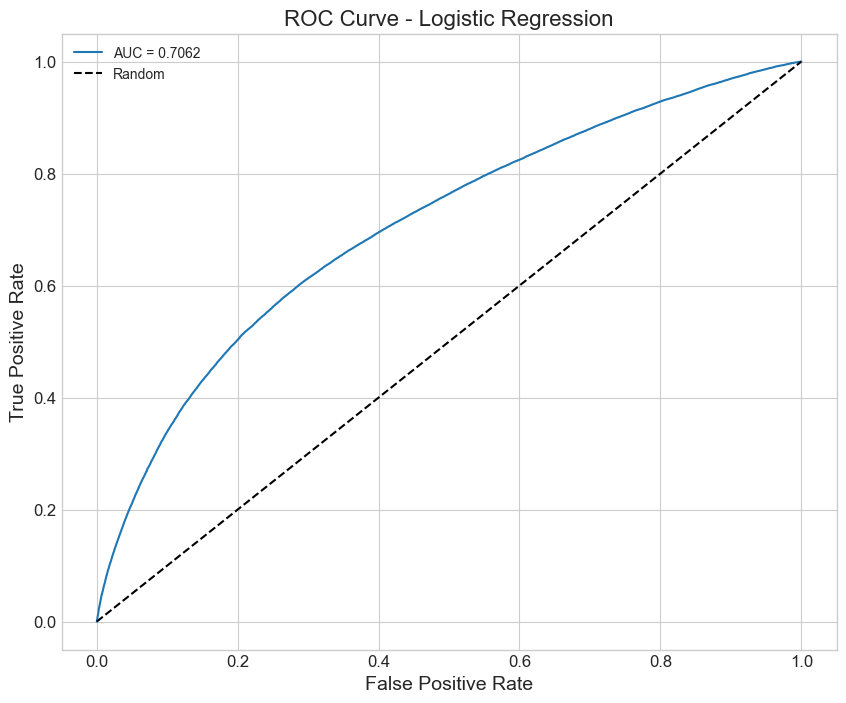

Optimal threshold: 0.4843


In [ ]:
plt.figure(figsize=(10, 8))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


roc_df = pd.DataFrame(
    {"fpr": fpr, "tpr": tpr, "threshold": thresholds, "difference": tpr - fpr}
)
optimal_threshold = roc_df.loc[roc_df["difference"].idxmax(), "threshold"]
print(f"Optimal threshold: {optimal_threshold:.4f}")

## Model 2: LightGBM

In [ ]:
print("\nTraining LightGBM model...")

gbm = lgb.LGBMClassifier(
    boosting_type="gbdt",
    learning_rate=0.1,
    n_estimators=200,
    num_leaves=32,
    random_state=42,
    n_jobs=-1,
    verbose=50
)


gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=["auc", "binary_logloss"],
    callbacks=[
        lgb.early_stopping(20)
    ],  
    
)

y_pred_proba_gbm = gbm.predict_proba(X_test)[:, 1]
y_pred_gbm = (y_pred_proba_gbm >= 0.5).astype(int)


print("\nLightGBM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gbm):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_gbm):.4f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_gbm)
print(
    pd.DataFrame(
        cm,
        columns=["Predicted Not Buy", "Predicted Buy"],
        index=["Actual Not Buy", "Actual Buy"],
    )
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gbm))


Training LightGBM model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 407922, number of negative: 407591
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.144498
[LightGBM] [Debug] init for col-wise cost 0.000238 seconds, init for row-wise cost 0.015897 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Dense Multi-Val Bin
[LightGBM] [Info] Total Bins 1145
[LightGBM] [Info] Number of data points in the train set: 815513, number of used features: 18
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500203 -> initscore=0.000812
[LightGBM] [Info] Start training from score 0.000812
[LightGBM] [Debug] Trained a tr

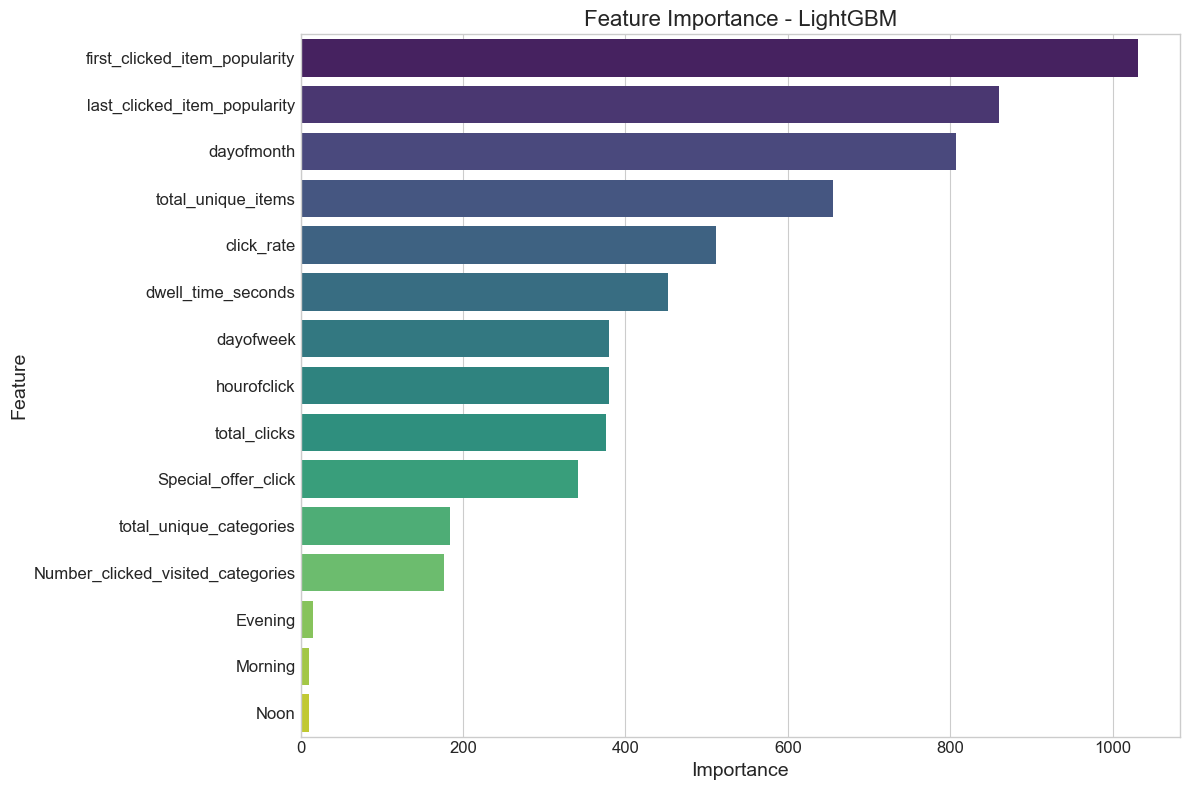

In [ ]:
plt.figure(figsize=(12, 8))

feature_imp = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': gbm.feature_importances_
})

feature_imp = feature_imp.sort_values('Importance', ascending=False).head(15)

sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title("Feature Importance - LightGBM", fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.tight_layout()
plt.show()


## Model 3: Random Forest

In [ ]:
print("\nTraining Random Forest model...")

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=10, random_state=42, n_jobs=-1
)

rf.fit(X_train, y_train)


y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_pred_proba_rf >= 0.5).astype(int)


print("\nRandom Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
print(
    pd.DataFrame(
        cm,
        columns=["Predicted Not Buy", "Predicted Buy"],
        index=["Actual Not Buy", "Actual Buy"],
    )
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Training Random Forest model...

Random Forest Results:
Accuracy: 0.7082
AUC: 0.7726

Confusion Matrix:
                Predicted Not Buy  Predicted Buy
Actual Not Buy              72519          29586
Actual Buy                  29900          71874

Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.71      0.71    102105
         1.0       0.71      0.71      0.71    101774

    accuracy                           0.71    203879
   macro avg       0.71      0.71      0.71    203879
weighted avg       0.71      0.71      0.71    203879



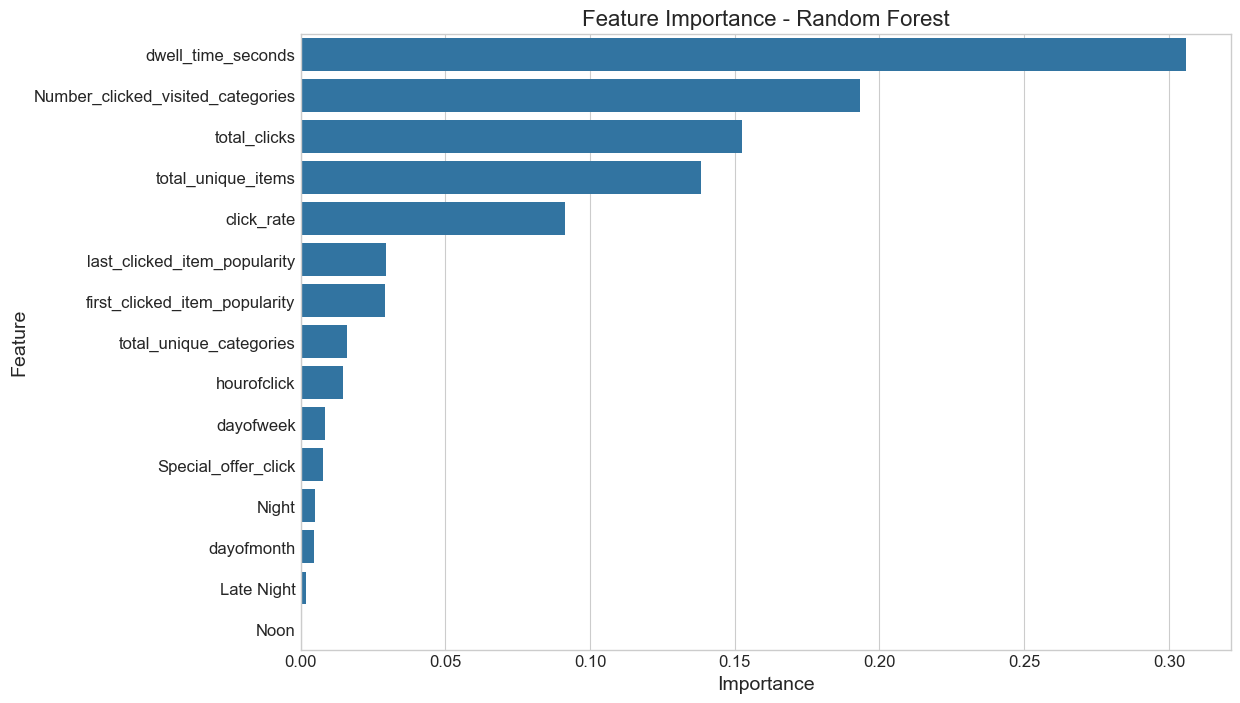

In [ ]:
plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": rf.feature_importances_}
).sort_values("Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feature_importance.head(15))
plt.title("Feature Importance - Random Forest")
plt.show()

## Model 4: Neural Network (PyTorch)

In [ ]:
print("\nTraining Neural Network model with PyTorch...")

class BinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, 32)
        self.dropout1 = nn.Dropout(0.2)
        self.layer2 = nn.Linear(32, 16)
        self.dropout2 = nn.Dropout(0.2)
        self.layer3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout1(x)
        x = self.relu(self.layer2(x))
        x = self.dropout2(x)
        x = self.sigmoid(self.layer3(x))
        return x



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


Training Neural Network model with PyTorch...


#### Initialize model, loss and optimizer

In [37]:
model = BinaryClassifier(input_dim=X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Training loop

In [ ]:
epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float("inf")
best_model_state = None
patience = 10
patience_counter = 0

In [ ]:
print("Starting training...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        predicted = (outputs >= 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    
    train_loss = train_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs >= 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    
    val_loss = val_loss / len(test_loader.dataset)
    val_accuracy = correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}"
        )

Starting training...
Epoch [5/50], Train Loss: 0.5791, Train Acc: 0.7060, Val Loss: 0.5716, Val Acc: 0.7099
Epoch [10/50], Train Loss: 0.5775, Train Acc: 0.7076, Val Loss: 0.5723, Val Acc: 0.7106
Epoch [15/50], Train Loss: 0.5770, Train Acc: 0.7082, Val Loss: 0.5697, Val Acc: 0.7121
Epoch [20/50], Train Loss: 0.5767, Train Acc: 0.7082, Val Loss: 0.5698, Val Acc: 0.7122
Epoch [25/50], Train Loss: 0.5765, Train Acc: 0.7084, Val Loss: 0.5699, Val Acc: 0.7114
Epoch [30/50], Train Loss: 0.5763, Train Acc: 0.7087, Val Loss: 0.5696, Val Acc: 0.7117
Epoch [35/50], Train Loss: 0.5762, Train Acc: 0.7086, Val Loss: 0.5692, Val Acc: 0.7122
Early stopping at epoch 37


In [ ]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_proba_nn = model(X_test_tensor).cpu().numpy().flatten()
    y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

In [ ]:
history = {
    "loss": train_losses,
    "val_loss": val_losses,
    "accuracy": train_accuracies,
    "val_accuracy": val_accuracies,
}

In [ ]:
print("\nNeural Network Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_nn):.4f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_nn)
print(
    pd.DataFrame(
        cm,
        columns=["Predicted Not Buy", "Predicted Buy"],
        index=["Actual Not Buy", "Actual Buy"],
    )
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))


Neural Network Results:
Accuracy: 0.7120
AUC: 0.7766

Confusion Matrix:
                Predicted Not Buy  Predicted Buy
Actual Not Buy              71621          30484
Actual Buy                  28243          73531

Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.70      0.71    102105
         1.0       0.71      0.72      0.71    101774

    accuracy                           0.71    203879
   macro avg       0.71      0.71      0.71    203879
weighted avg       0.71      0.71      0.71    203879



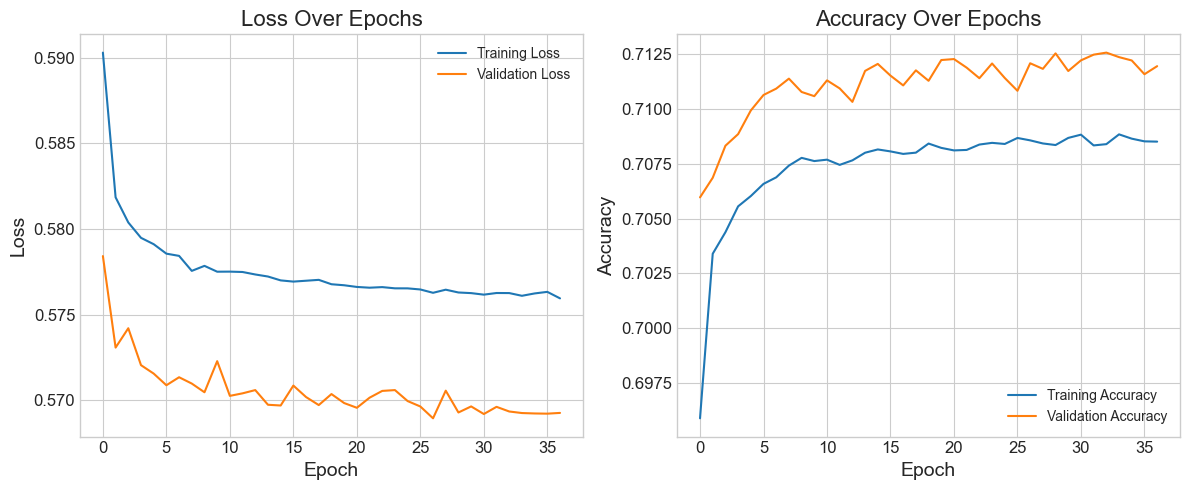

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Compare Models

In [45]:
print("\nModel Comparison:")
model_comparison = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "LightGBM", "Random Forest", "Neural Network"],
        "Accuracy": [
            accuracy_score(y_test, y_pred_lr),
            accuracy_score(y_test, y_pred_gbm),
            accuracy_score(y_test, y_pred_rf),
            accuracy_score(y_test, y_pred_nn),
        ],
        "AUC": [
            roc_auc_score(y_test, y_pred_proba_lr),
            roc_auc_score(y_test, y_pred_proba_gbm),
            roc_auc_score(y_test, y_pred_proba_rf),
            roc_auc_score(y_test, y_pred_proba_nn),
        ],
        "Precision": [
            precision_score(y_test, y_pred_lr),
            precision_score(y_test, y_pred_gbm),
            precision_score(y_test, y_pred_rf),
            precision_score(y_test, y_pred_nn),
        ],
        "Recall": [
            recall_score(y_test, y_pred_lr),
            recall_score(y_test, y_pred_gbm),
            recall_score(y_test, y_pred_rf),
            recall_score(y_test, y_pred_nn),
        ],
        "F1 Score": [
            f1_score(y_test, y_pred_lr),
            f1_score(y_test, y_pred_gbm),
            f1_score(y_test, y_pred_rf),
            f1_score(y_test, y_pred_nn),
        ],
    }
)

print(model_comparison.set_index("Model").round(4))


Model Comparison:
                     Accuracy     AUC  Precision  Recall  F1 Score
Model                                                             
Logistic Regression    0.6557  0.7062     0.6929  0.5573    0.6178
LightGBM               0.7232  0.7931     0.7216  0.7254    0.7235
Random Forest          0.7082  0.7726     0.7084  0.7062    0.7073
Neural Network         0.7120  0.7766     0.7069  0.7225    0.7146


#### Logistic Regression

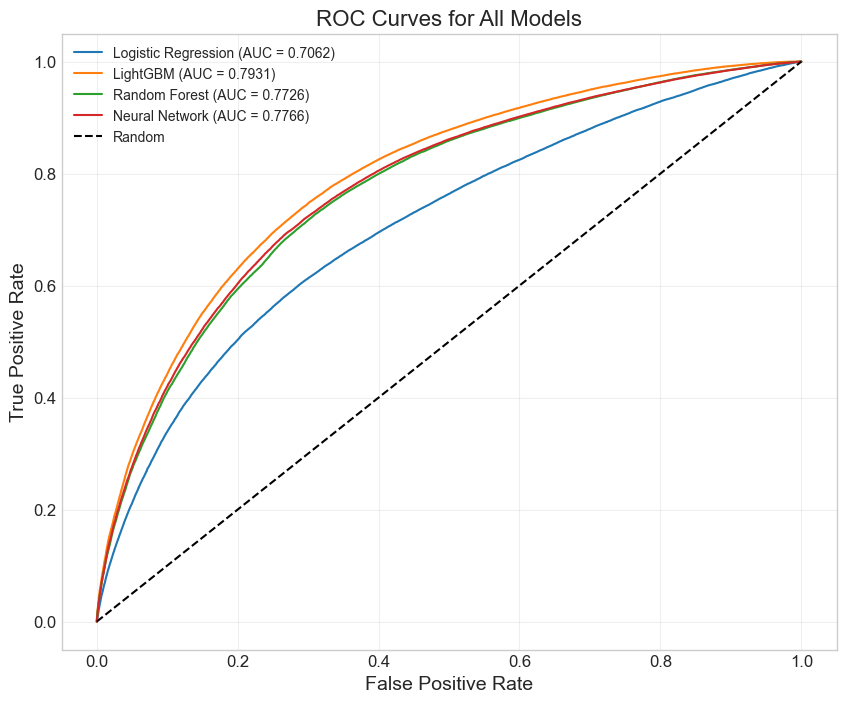

In [ ]:
plt.figure(figsize=(10, 8))


fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.4f})",
)

fpr_gbm, tpr_gbm, _ = roc_curve(y_test, y_pred_proba_gbm)
plt.plot(
    fpr_gbm,
    tpr_gbm,
    label=f"LightGBM (AUC = {roc_auc_score(y_test, y_pred_proba_gbm):.4f})",
)


fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.4f})",
)



fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_proba_nn)
plt.plot(
    fpr_nn,
    tpr_nn,
    label=f"Neural Network (AUC = {roc_auc_score(y_test, y_pred_proba_nn):.4f})",
)

plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()